# Requirements text file

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Loading the datasets**

In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Dataset 1 - SumArabic
try:
    SumArabic_tr = pd.read_json(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\sumarabic-1.0-train.jsonl", lines=True)
    SumArabic_te = pd.read_json(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\sumarabic-1.0-test.jsonl",  lines=True)
    SumArabic_va = pd.read_json(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\sumarabic-1.0-valid.jsonl", lines=True)

    SumArabic_tr = SumArabic_tr[["text", "headline"]].rename(columns={"headline": "summary"})
    SumArabic_te = SumArabic_te[["text", "headline"]].rename(columns={"headline": "summary"})
    SumArabic_va = SumArabic_va[["text", "headline"]].rename(columns={"headline": "summary"})

    df_sumarabic = pd.concat([SumArabic_tr, SumArabic_te, SumArabic_va], ignore_index=True)
    df_sumarabic['source_dataset'] = 'SumArabic'
    print(f"✅ SumArabic loaded: {len(df_sumarabic)} rows")
except Exception as e:
    print(f"SumArabic error: {e}")
    df_sumarabic = pd.DataFrame(columns=['text', 'summary', 'source_dataset'])

# Dataset 2 - AraSum
try:
    df_arasum = pd.read_csv(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\AraSum.txt", sep="\t", engine="python",
                             header=None, names=["index", "text", "summary"],
                             encoding='utf-8', encoding_errors='ignore')
    df_arasum = df_arasum.drop("index", axis=1).dropna()
    df_arasum['source_dataset'] = 'AraSum'
    print(f"✅ AraSum loaded: {len(df_arasum)} rows")
except Exception as e:
    print(f"AraSum error: {e}")
    df_arasum = pd.DataFrame(columns=['text', 'summary', 'source_dataset'])

# Dataset 3 - Egyptian
try:
    df_egyptian = pd.read_parquet(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\train-00000-of-00001.parquet", engine="pyarrow")
    df_egyptian = df_egyptian[["text", "summarized_text"]].rename(columns={"summarized_text": "summary"})
    df_egyptian = df_egyptian.dropna()
    df_egyptian['source_dataset'] = 'Egyptian'
    print(f"✅ Egyptian loaded: {len(df_egyptian)} rows")
except Exception as e:
    print(f"Egyptian error: {e}")
    df_egyptian = pd.DataFrame(columns=['text', 'summary', 'source_dataset'])

# Dataset 4 - Kaggle
try:
    df_kaggle = pd.read_csv(r"C:\Users\hamze\OneDrive\Desktop\NLP Project\NLP Datasets\summarizdataset.txt")
    df_kaggle = df_kaggle[["text", "summarizer"]].rename(columns={"summarizer": "summary"})
    df_kaggle = df_kaggle.dropna()
    df_kaggle['source_dataset'] = 'Kaggle'
    print(f"✅ Kaggle loaded: {len(df_kaggle)} rows")
except Exception as e:
    print(f"Kaggle error: {e}")
    df_kaggle = pd.DataFrame(columns=['text', 'summary', 'source_dataset'])

# Merge
print("\nMerging datasets...")
master_df = pd.concat([df_sumarabic, df_arasum, df_egyptian, df_kaggle], ignore_index=True)
master_df = master_df.rename(columns={'text': 'document'})
master_df['document'] = master_df['document'].astype(str)
master_df['summary']  = master_df['summary'].astype(str)
master_df = master_df.drop_duplicates(subset=['document'])
master_df = master_df[(master_df['document'] != 'nan') & (master_df['summary'] != 'nan')]

print("=" * 45)
print(f" UNIQUE DOCUMENTS: {len(master_df):,} ")
print("=" * 45)
print("\nBreakdown by source:")
print(master_df['source_dataset'].value_counts().to_string())

✅ SumArabic loaded: 2628 rows
✅ AraSum loaded: 49604 rows
✅ Egyptian loaded: 3689 rows
✅ Kaggle loaded: 8378 rows

Merging datasets...
 UNIQUE DOCUMENTS: 63,952 

Breakdown by source:
source_dataset
AraSum       49580
Kaggle        8055
Egyptian      3689
SumArabic     2628


# **Explaratory Data Analysis**

In [3]:
master_df.columns

Index(['document', 'summary', 'source_dataset'], dtype='str')

--- sequence length statistics ---


,doc_len,sum_len,compression_ratio
count,63952.000000,63952.000000,63952.000000
mean,310.120559,32.586674,0.186815
std,234.284839,10.558751,0.182552
min,11.000000,2.000000,0.006173
25%,140.000000,29.000000,0.080378
50%,260.000000,34.000000,0.125506
75%,415.000000,36.000000,0.210526
max,2898.000000,88.000000,1.057143


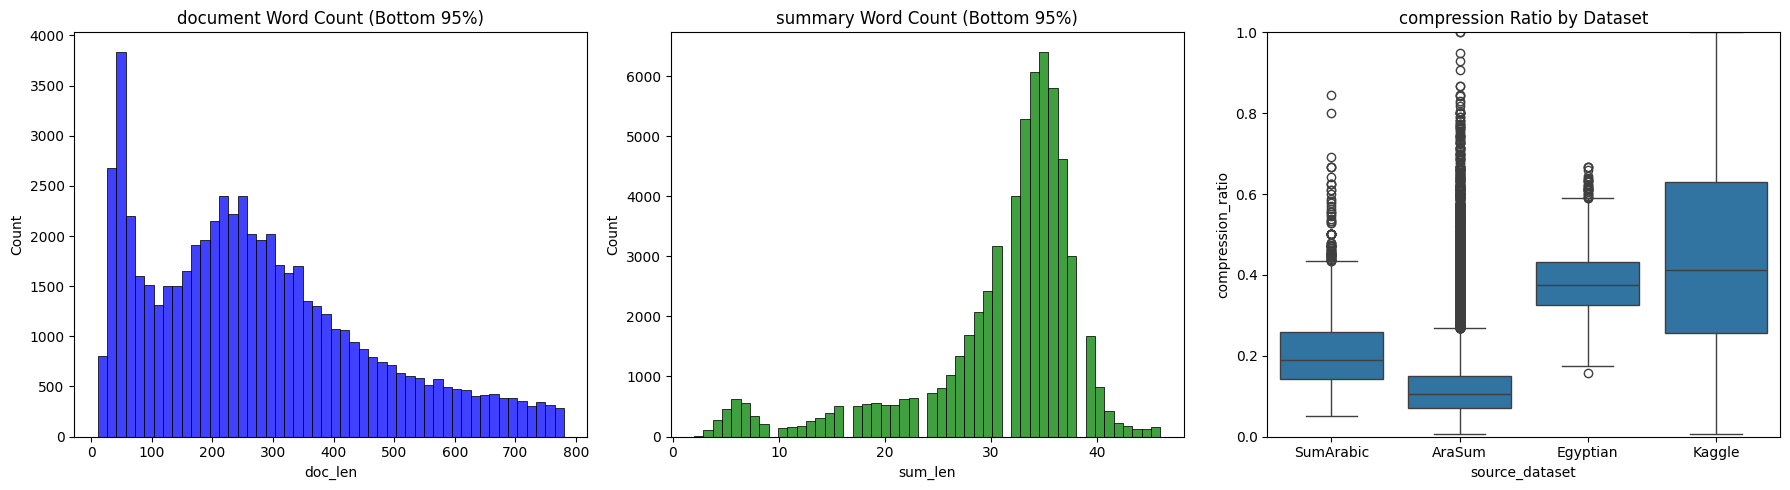

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

master_df['doc_len'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['sum_len'] = master_df['summary'].apply(lambda x: len(str(x).split()))
master_df['compression_ratio'] = master_df['sum_len'] / master_df['doc_len']

master_df.replace([np.inf, -np.inf], np.nan, inplace=True)
master_df.dropna(subset=['compression_ratio'], inplace=True)

print("--- sequence length statistics ---")
display(master_df[['doc_len', 'sum_len', 'compression_ratio']].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

doc_cap = master_df['doc_len'].quantile(0.95)
sns.histplot(master_df[master_df['doc_len'] < doc_cap]['doc_len'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('document Word Count (Bottom 95%)')

sum_cap = master_df['sum_len'].quantile(0.95)
sns.histplot(master_df[master_df['sum_len'] < sum_cap]['sum_len'], bins=50, ax=axes[1], color='green')
axes[1].set_title('summary Word Count (Bottom 95%)')

sns.boxplot(x='source_dataset', y='compression_ratio', data=master_df, ax=axes[2])
axes[2].set_title('compression Ratio by Dataset')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# **Data Preprocessing**

In [5]:
import re
import pandas as pd
import numpy as np

master_df['doc_len'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['sum_len'] = master_df['summary'].apply(lambda x: len(str(x).split()))
master_df['ratio'] = master_df['sum_len'] / master_df['doc_len']
master_df = master_df[(master_df['ratio'] < 1.0) & (master_df['ratio'] > 0.05)].copy()

master_df = (
    master_df.groupby('source_dataset', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 15000), random_state=42))
    .reset_index(drop=True)
)

master_df = master_df[master_df['summary'].apply(lambda x: len(str(x).split()) >= 5)]
master_df = master_df[master_df['document'].apply(lambda x: len(str(x).split()) >= 20)]

def clean_arabic(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|[a-zA-Z]', '', text)
    text = re.sub(r'[\u064B-\u065F\u0640]', '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'([^\w\s\ا-ي0-9\.،؟])', r' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

master_df['clean_doc'] = master_df['document'].apply(clean_arabic)
master_df['clean_summary'] = master_df['summary'].apply(lambda x: f"sostok {clean_arabic(x)} eostok")

clean_df = master_df[
    (master_df['clean_doc'].str.split().str.len().between(1, 400)) &
    (master_df['clean_summary'].str.split().str.len().between(3, 50))
][['clean_doc', 'clean_summary']].copy()

print(f"clean samples: {len(clean_df)}")

clean samples: 20975


In [6]:

import pickle
import numpy as np
from collections import Counter

import pickle
import numpy as np
from collections import Counter

class SimpleTokenizer:
    def __init__(self, num_words=40000, oov_token='<UNK>'):
        self.num_words = num_words
        self.oov_token = oov_token
        self.word_index = {}
        self.index_word = {}
        self.word_counts = Counter()

    def fit_on_texts(self, texts):
        for text in texts:
            self.word_counts.update(str(text).split())
        most_common = self.word_counts.most_common(self.num_words - 2)
        self.word_index = {self.oov_token: 1}
        for i, (word, count) in enumerate(most_common):
            self.word_index[word] = i + 2
        self.index_word = {i: w for w, i in self.word_index.items()}

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            seq = [self.word_index.get(word, 1) for word in str(text).split()]
            sequences.append(seq)
        return sequences

def pad_sequences(sequences, maxlen=None, padding='post', value=0):
    num_samples = len(sequences)
    if maxlen is None:
        maxlen = max(len(s) for s in sequences) if sequences else 0

    padded_seqs = np.full((num_samples, maxlen), value)
    for i, seq in enumerate(sequences):
        if len(seq) == 0:
            continue
        if len(seq) > maxlen:
            trunc = seq[:maxlen]
        else:
            trunc = seq

        if padding == 'post':
            padded_seqs[i, :len(trunc)] = trunc
        else:
            padded_seqs[i, -len(trunc):] = trunc
    return padded_seqs

import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MAX_ENC_LEN   = 400
MAX_DEC_LEN   = 50
VOCAB_SIZE     = 40000
LATENT_DIM     = 256
EMBEDDING_DIM  = 300

docs      = list(clean_df['clean_doc'])
summaries = list(clean_df['clean_summary'])

docs_train, docs_temp, sums_train, sums_temp = train_test_split(docs, summaries, test_size=0.2, random_state=42)
docs_val, docs_test, sums_val, sums_test     = train_test_split(docs_temp, sums_temp, test_size=0.5, random_state=42)

shared_tok = SimpleTokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
shared_tok.fit_on_texts(docs_train + sums_train)

assert 'sostok' in shared_tok.word_index, "sostok missing!"
assert 'eostok' in shared_tok.word_index, "eostok missing!"

enc_train = pad_sequences(shared_tok.texts_to_sequences(docs_train), maxlen=MAX_ENC_LEN, padding='post')
enc_val   = pad_sequences(shared_tok.texts_to_sequences(docs_val),   maxlen=MAX_ENC_LEN, padding='post')
enc_test  = pad_sequences(shared_tok.texts_to_sequences(docs_test),  maxlen=MAX_ENC_LEN, padding='post')

dec_train = pad_sequences(shared_tok.texts_to_sequences(sums_train), maxlen=MAX_DEC_LEN, padding='post')
dec_val   = pad_sequences(shared_tok.texts_to_sequences(sums_val),   maxlen=MAX_DEC_LEN, padding='post')
dec_test  = pad_sequences(shared_tok.texts_to_sequences(sums_test),  maxlen=MAX_DEC_LEN, padding='post')

print(f"Shared vocab size : {len(shared_tok.word_index):,}")
print(f"enc_train shape   : {enc_train.shape}")
print(f"dec_train shape   : {dec_train.shape}")

Using device: cuda
Shared vocab size : 39,999
enc_train shape   : (16780, 400)
dec_train shape   : (16780, 50)


# Model Design

In [ ]:
import torch.utils.checkpoint
import torch.nn as nn
import fasttext
import fasttext.util
import os


EMBEDDING_DIM = 300

ft = fasttext.load_model(r'C:\Users\hamze\OneDrive\Desktop\NLP Project\cc.ar.300.bin')
print(f"FastText loaded. Dimension: {ft.get_dimension()}")


shared_emb = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM, padding_idx=0).to(device)

loaded = 0
with torch.no_grad():
    for word, idx in shared_tok.word_index.items():
        if 0 < idx < VOCAB_SIZE:
            vec = torch.tensor(ft.get_word_vector(word), dtype=torch.float)
            shared_emb.weight[idx] = vec
            loaded += 1

print(f"Loaded {loaded:,} / {len(shared_tok.word_index):,} pretrained vectors ({100*loaded/len(shared_tok.word_index):.1f}%)")

shared_emb.weight.requires_grad = True


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = shared_emb
        self.lstm      = nn.LSTM(EMBEDDING_DIM, LATENT_DIM, batch_first=True,
                                 bidirectional=True, dropout=0.3, num_layers=2)
    def _lstm_forward(self, emb):
        return self.lstm(emb)
    def forward(self, x):
        emb = self.embedding(x)
        outputs, (h, c) = torch.utils.checkpoint.checkpoint(
            self._lstm_forward, emb, use_reentrant=False
        )
        h = torch.cat([h[-2], h[-1]], dim=1)
        c = torch.cat([c[-2], c[-1]], dim=1)
        return outputs, h, c

class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.W1 = nn.Linear(LATENT_DIM * 2, LATENT_DIM * 2)
        self.W2 = nn.Linear(LATENT_DIM * 2, LATENT_DIM * 2)
        self.V  = nn.Linear(LATENT_DIM * 2, 1)
    def forward(self, decoder_hidden, encoder_outputs):
        dh      = decoder_hidden.unsqueeze(1)
        score   = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(dh)))
        weights = torch.softmax(score, dim=1)
        context = (weights * encoder_outputs).sum(dim=1)
        return context

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = shared_emb
        self.lstm      = nn.LSTM(EMBEDDING_DIM + LATENT_DIM * 2, LATENT_DIM * 2,
                                 batch_first=True, dropout=0.3)
        self.attention = BahdanauAttention()
        self.fc1       = nn.Linear(LATENT_DIM * 4, LATENT_DIM * 2)
        self.fc2       = nn.Linear(LATENT_DIM * 2, VOCAB_SIZE)
        self.relu      = nn.ReLU()
        self.dropout   = nn.Dropout(0.3)
    def forward(self, x, h, c, encoder_outputs):
        emb     = self.embedding(x)
        context = self.attention(h.squeeze(0), encoder_outputs).unsqueeze(1)
        out, (h, c) = self.lstm(torch.cat([emb, context], dim=2), (h, c))
        pred = self.fc2(self.dropout(self.relu(self.fc1(torch.cat([out.squeeze(1), context.squeeze(1)], dim=1)))))
        return pred, h, c

class Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, src, trg):
        enc_out, h, c = self.encoder(src)
        h = h.unsqueeze(0)
        c = c.unsqueeze(0)
        outputs = []
        inp = trg[:, 0].unsqueeze(1)
        for t in range(trg.shape[1]):
            pred, h, c = self.decoder(inp, h, c, enc_out)
            outputs.append(pred.unsqueeze(1))
            inp = trg[:, t + 1].unsqueeze(1) if t + 1 < trg.shape[1] else trg[:, -1].unsqueeze(1)
        return torch.cat(outputs, dim=1)

model = Seq2Seq().to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

FastText loaded. Dimension: 300
Loaded 39,999 / 39,999 pretrained vectors (100.0%)
Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(40000, 300, padding_idx=0)
    (lstm): LSTM(300, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(40000, 300, padding_idx=0)
    (lstm): LSTM(812, 512, batch_first=True, dropout=0.3)
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (V): Linear(in_features=512, out_features=1, bias=True)
    )
    (fc1): Linear(in_features=1024, out_features=512, bias=True)
    (fc2): Linear(in_features=512, out_features=40000, bias=True)
    (relu): ReLU()
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

Total trainable parameters: 39,006,017


# Data Preperation

In [8]:
dec_train_input  = dec_train[:, :-1]
dec_train_target = dec_train[:, 1:]
dec_val_input    = dec_val[:, :-1]
dec_val_target   = dec_val[:, 1:]

class SummarizationDataset(Dataset):
    def __init__(self, enc, dec, target):
        self.enc    = torch.tensor(enc,    dtype=torch.long)
        self.dec    = torch.tensor(dec,    dtype=torch.long)
        self.target = torch.tensor(target, dtype=torch.long)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx], self.target[idx]

train_loader = DataLoader(SummarizationDataset(enc_train, dec_train_input, dec_train_target), batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(SummarizationDataset(enc_val,   dec_val_input,   dec_val_target),   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(f"Encoder train         : {enc_train.shape}")
print(f"Decoder input train   : {dec_train_input.shape}")
print(f"Decoder target train  : {dec_train_target.shape}")

Encoder train         : (16780, 400)
Decoder input train   : (16780, 49)
Decoder target train  : (16780, 49)


In [9]:
print("enc_train max:", enc_train.max())
print("dec_train max:", dec_train.max())
print("enc_val max:", enc_val.max())
print("dec_val max:", dec_val.max())
print("VOCAB_SIZE:", VOCAB_SIZE)

assert enc_train.max() < VOCAB_SIZE
assert dec_train.max() < VOCAB_SIZE
assert enc_val.max() < VOCAB_SIZE
assert dec_val.max() < VOCAB_SIZE

print("All token IDs are valid.")

enc_train max: 39999
dec_train max: 39999
enc_val max: 39998
dec_val max: 39978
VOCAB_SIZE: 40000
All token IDs are valid.


# Training Part

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from tqdm import tqdm

torch.backends.cudnn.benchmark = True
torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scaler = GradScaler() if device.type == 'cuda' else None

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
)

best_val_loss  = float('inf')
patience_count = 0
PATIENCE       = 5
best_weights   = None

for epoch in range(20):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for src, trg, target in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        src, trg, target = src.to(device), trg.to(device), target.to(device)
        optimizer.zero_grad()

        with autocast(device_type=device.type):
            output      = model(src, trg)
            output_flat = output.reshape(-1, VOCAB_SIZE)
            target_flat = target.reshape(-1)
            loss        = criterion(output_flat, target_flat)

        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        train_loss += loss.item()
        mask = target_flat != 0
        train_correct += (output_flat.argmax(1)[mask] == target_flat[mask]).sum().item()
        train_total   += mask.sum().item()

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for src, trg, target in val_loader:
            src, trg, target = src.to(device), trg.to(device), target.to(device)
            with autocast(device_type=device.type):
                output      = model(src, trg)
                output_flat = output.reshape(-1, VOCAB_SIZE)
                target_flat = target.reshape(-1)
                val_loss   += criterion(output_flat, target_flat).item()
                mask        = target_flat != 0
                val_correct += (output_flat.argmax(1)[mask] == target_flat[mask]).sum().item()
                val_total   += mask.sum().item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)

    print(
        f"Epoch {epoch+1:02d}/20 | "
        f"Train Loss: {avg_train:.4f} Acc: {train_correct/train_total:.4f} | "
        f"Val Loss: {avg_val:.4f} Acc: {val_correct/val_total:.4f}"
    )

    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        best_weights   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_count = 0
        torch.save({
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict'   : scaler.state_dict() if scaler else None,
            'epoch'               : epoch,
            'best_val_loss'       : best_val_loss
        }, 'checkpoint.pt')
        print("Checkpoint saved successfully")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

if best_weights:
    model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
print("Training Completed")

torch.save({
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'scaler_state_dict'   : scaler.state_dict() if scaler else None,
    'epoch'               : epoch,
    'best_val_loss'       : best_val_loss
}, 'checkpoint.pt')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(shared_tok, f)
print("Checkpoint saved successfully")

Epoch 1: 100%|██████████| 525/525 [03:47<00:00,  2.31it/s]


Epoch 01/20 | Train Loss: 8.0518 Acc: 0.0953 | Val Loss: 7.4241 Acc: 0.1298
Checkpoint saved successfully


Epoch 2: 100%|██████████| 525/525 [03:43<00:00,  2.35it/s]


Epoch 02/20 | Train Loss: 7.1894 Acc: 0.1369 | Val Loss: 6.8772 Acc: 0.1587
Checkpoint saved successfully


Epoch 3: 100%|██████████| 525/525 [03:43<00:00,  2.35it/s]


...

Epoch 08/20 | Train Loss: 4.1681 Acc: 0.2699 | Val Loss: 6.9710 Acc: 0.2016


Epoch 9: 100%|██████████| 525/525 [03:37<00:00,  2.42it/s]


Epoch 09/20 | Train Loss: 3.5946 Acc: 0.3198 | Val Loss: 7.4470 Acc: 0.1937


Epoch 10: 100%|██████████| 525/525 [03:37<00:00,  2.42it/s]


Epoch 10/20 | Train Loss: 3.2626 Acc: 0.3593 | Val Loss: 7.8718 Acc: 0.1892
Early stopping at epoch 10
Training Completed
Checkpoint saved successfully


# Training process loaded

In [11]:
checkpoint = torch.load('checkpoint.pt', map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
scaler.load_state_dict(checkpoint['scaler_state_dict'])

start_epoch   = checkpoint['epoch']
best_val_loss = checkpoint['best_val_loss']

with open('tokenizer.pkl', 'rb') as f:
    shared_tok = pickle.load(f)

model.to(device)
model.eval()

print(f"Loaded checkpoint from epoch {start_epoch}")

Loaded checkpoint from epoch 9


# Inference Model

In [ ]:
import random

def decode_greedy(input_seq):
    model.eval()
    word_index    = shared_tok.word_index
    reverse_vocab = shared_tok.index_word

    with torch.no_grad():
        src = torch.tensor(input_seq, dtype=torch.long).to(device)
        enc_out, h, c = model.encoder(src)
        h = h.unsqueeze(0)
        c = c.unsqueeze(0)
        inp     = torch.tensor([[word_index['sostok']]], dtype=torch.long).to(device)
        summary = ''
        last_valid_idx = word_index['sostok'] 

        for _ in range(MAX_DEC_LEN - 1):
            pred, h, c = model.decoder(inp, h, c, enc_out)
            token_idx  = pred.argmax(dim=1).item()
            token      = reverse_vocab.get(token_idx, '')

            if token == 'eostok':
                break
            elif token in ('', '<UNK>'):
                inp = torch.tensor([[last_valid_idx]], dtype=torch.long).to(device)
            else:
                summary += ' ' + token
                last_valid_idx = token_idx
                inp = torch.tensor([[token_idx]], dtype=torch.long).to(device)

    return summary.strip()


def decode_beam(input_seq, beam_width=5, length_penalty=0.7):
    model.eval()
    word_index    = shared_tok.word_index
    reverse_vocab = shared_tok.index_word
    sos_idx = word_index['sostok']
    eos_idx = word_index['eostok']

    with torch.no_grad():
        src = torch.tensor(input_seq, dtype=torch.long).to(device)
        enc_out, h, c = model.encoder(src)
        h = h.unsqueeze(0)
        c = c.unsqueeze(0)

        beams     = [(0.0, [sos_idx], h, c)]
        completed = []

        for _ in range(MAX_DEC_LEN - 1):
            if not beams:
                break
            candidates = []

            for score, tokens, bh, bc in beams:
                inp  = torch.tensor([[tokens[-1]]], dtype=torch.long).to(device)
                pred, nh, nc = model.decoder(inp, bh, bc, enc_out)
                log_probs    = torch.log_softmax(pred, dim=1)
                top_probs, top_idx = log_probs.topk(beam_width)

                for k in range(beam_width):
                    tok       = top_idx[0, k].item()
                    new_score = score + top_probs[0, k].item()
                    candidates.append((new_score, tokens + [tok], nh, nc))

            # Sort by length-penalised score
            candidates.sort(
                key=lambda x: x[0] / (max(len(x[1]), 1) ** length_penalty),
                reverse=True
            )

            beams = []
            for cand in candidates[:beam_width]:
                if cand[1][-1] == eos_idx:
                    completed.append(cand)
                else:
                    beams.append(cand)

        all_cands = completed if completed else beams
        best = max(all_cands,
                   key=lambda x: x[0] / (max(len(x[1]), 1) ** length_penalty))

        tokens  = best[1][1:]  
        skip    = {'', '<UNK>', 'eostok', 'sostok'}
        summary = ' '.join(
            reverse_vocab.get(t, '') for t in tokens
            if t != eos_idx and reverse_vocab.get(t, '') not in skip
        )

    return summary.strip()


print("Inference functions ready: decode_greedy | decode_beam")

Inference functions ready: decode_greedy | decode_beam


In [13]:
device = torch.device('cpu')
model  = model.cpu()

# Evaluation(ROUGE)

In [ ]:
from rouge_score import rouge_scorer as rs
import numpy as np

scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

greedy_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}
beam_scores   = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for i in range(min(20, len(enc_test))):
    ref = sums_test[i].replace('sostok', '').replace('eostok', '').strip()

    pred_g = decode_greedy(enc_test[i].reshape(1, MAX_ENC_LEN))
    pred_b = decode_beam  (enc_test[i].reshape(1, MAX_ENC_LEN))

    for k in greedy_scores:
        greedy_scores[k].append(scorer.score(ref, pred_g)[k].fmeasure)
        beam_scores  [k].append(scorer.score(ref, pred_b)[k].fmeasure)

print("=" * 54)
print(f"{'METRIC':<10} {'GREEDY':>10} {'BEAM (w=5)':>12}")
print("=" * 54)
for k in ['rouge1', 'rouge2', 'rougeL']:
    g = np.mean(greedy_scores[k])
    b = np.mean(beam_scores[k])
    diff = b - g
    arrow = '▲' if diff > 0 else '▼'
    print(f"  {k.upper():<8} {g:>10.4f} {b:>12.4f}   {arrow} {abs(diff):.4f}")
print("=" * 54)

print("\n" + "═" * 70)
print("  QUALITATIVE SAMPLES (3 examples)")
print("═" * 70)

for i in range(3):
    ref    = sums_test[i].replace('sostok', '').replace('eostok', '').strip()
    pred_g = decode_greedy(enc_test[i].reshape(1, MAX_ENC_LEN))
    pred_b = decode_beam  (enc_test[i].reshape(1, MAX_ENC_LEN))

    rl_g = scorer.score(ref, pred_g)['rougeL'].fmeasure
    rl_b = scorer.score(ref, pred_b)['rougeL'].fmeasure

    print(f"\n┌─ Sample {i+1} " + "─" * 57)
    print(f"│ Document   : {docs_test[i][:180]}...")
    print(f"│ Reference  : {ref}")
    print(f"│ Greedy     : {pred_g}  [ROUGE-L: {rl_g:.4f}]")
    print(f"│ Beam (w=5) : {pred_b}  [ROUGE-L: {rl_b:.4f}]")
    print(f"└" + "─" * 68)

METRIC         GREEDY   BEAM (w=5)
  ROUGE1       0.0000       0.0000   ▼ 0.0000
  ROUGE2       0.0000       0.0000   ▼ 0.0000
  ROUGEL       0.0000       0.0000   ▼ 0.0000

══════════════════════════════════════════════════════════════════════
  QUALITATIVE SAMPLES (3 examples)
══════════════════════════════════════════════════════════════════════

┌─ Sample 1 ─────────────────────────────────────────────────────────
│ Document   : تقدم الحكومه الالمانيه مساعدات تقنيه لتونس بقيمه 34 مليون يورو لتامين حدودها مع ليبيا. وقال متحدث باسم الحكومه الالمانيه في برلين اليوم الجمعه 15 كانون الاول ديسمبر 2017 انه تم تزو...
│ Reference  : قدمت الحكومه الالمانيه دعما ماليا لتونس بقيمه 34 مليون يورو لتامين حدودها مع ليبيا، يتضمن تزويد تونس بانظمه رادار متحركه وكاميرات واسعه المجال واجهزه مراقبه الكترونيه، وذلك لوقف تهريب اسلحه وارهابيين اليها من ليبيا.
│ Greedy     : في خطوه  [ROUGE-L: 0.0000]
│ Beam (w=5) : كشف تقرير صحفي ان عدد من اللاجئين من اجل في المانيا في الوقت الذي فيه عدد كبير من اللاجئين 

In [16]:

from bert_score import score as bert_score

print("Running BERTScore evaluation on 20 test samples...")

predictions = []
references  = []

for i in tqdm(range(min(20, len(enc_test)))):
    pred = decode_greedy(enc_test[i].reshape(1, MAX_ENC_LEN))
    ref  = sums_test[i].replace('sostok', '').replace('eostok', '').strip()
    predictions.append(pred if pred else '.')
    references.append(ref  if ref  else '.')

P, R, F1 = bert_score(
    predictions, references,
    model_type='aubmindlab/bert-base-arabertv2',
    num_layers=8,
    verbose=False,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("\n========= BERTSCORE (20 test samples) =========")
print(f"  Precision : {P.mean().item():.4f}")
print(f"  Recall    : {R.mean().item():.4f}")
print(f"  F1        : {F1.mean().item():.4f}")
print("=================================================")

Running BERTScore evaluation on 20 test samples...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2150.54it/s]
[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



========= BERTSCORE (20 test samples) =========
  Precision : 0.3911
  Recall    : 0.2959
  F1        : 0.3345
